In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)
classes = iris.target_names
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2,
random_state=42)

In [3]:
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
  model = Sequential()
  model.add(Dense(hidden_layers[0], input_dim=input_dim, activation=activation))
  for units in hidden_layers[1:]:
    model.add(Dense(units, activation=activation))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_mlp(input_dim, output_dim, hidden_layers, activation):
    model = Sequential()

    # Input layer
    model.add(Input(shape=(input_dim,)))

    # Hidden layers
    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    # Output layer
    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



In [10]:
hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
activations = ['relu', 'tanh', 'sigmoid']

for hidden_layers in hidden_layer_configs:
    for activation in activations:

        print(
            f"\nTesting MLP with hidden_layers={hidden_layers}, "
            f"activation={activation}"
        )

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        test_loss, test_acc = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print(
            f"Test Accuracy: {test_acc:.4f}, "
            f"Test Loss: {test_loss:.4f}"
        )



Testing MLP with hidden_layers=[8], activation=relu
Test Accuracy: 0.9333, Test Loss: 0.2049

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.1796

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.4503

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 1.0000, Test Loss: 0.0783

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 1.0000, Test Loss: 0.0795

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.4032

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 1.0000, Test Loss: 0.0295

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 1.0000, Test Loss: 0.0493

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3469


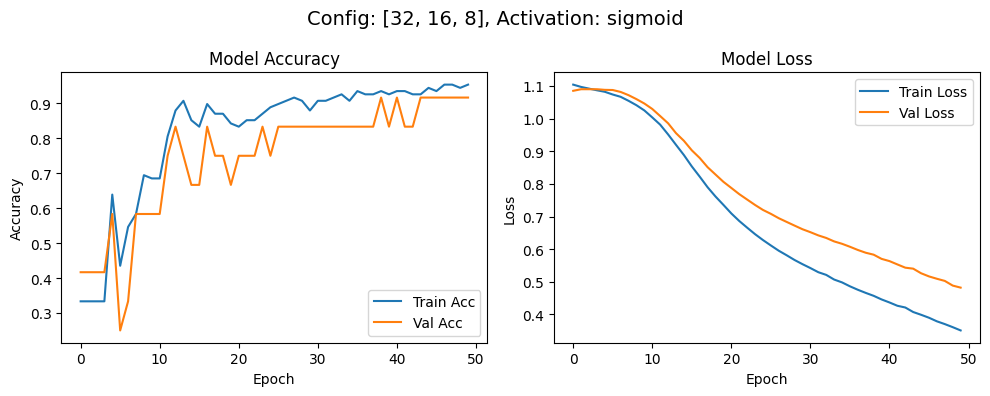

In [11]:

plt.figure(figsize=(10, 4))
plt.suptitle(f"Config: {hidden_layers}, Activation: {activation}", fontsize=14)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))
user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
user_input_scaled = scaler.transform(user_input)
# Predict using the last trained model
prediction = model.predict(user_input_scaled)
predicted_class_index = np.argmax(prediction)
predicted_class_name = classes[predicted_class_index]
print(f"\n🌸 Predicted Iris Species: {predicted_class_name}")

Sepal length (cm): 24
Sepal width (cm): 12
Petal length (cm): 22
Petal width (cm): 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

🌸 Predicted Iris Species: virginica
